## Ejercicio 1: Triangulación de Delaunay

In [3]:
# Importamos las librerias
import numpy as np          # Import NumPy for numerical operations and array handling
from PIL import Image      # Import PIL (Python Imaging Library) for image processing
import scipy.io as sio     # Import SciPy's IO module for reading .mat files
import matplotlib.pyplot as plt #Import Matplotlib 
import os                   # Import os for iterating directories

### Cargamos las imágenes

In [4]:
def cargar_imagenes(category):

    # Definimos tamaño objeto
    obj_resize = (256,256)

    ruta = './data/WillowObject/WILLOW-ObjectClass/' + category

    #Definimos las listas donde vamos a guardar los distintos elementos
    pngs = []
    mats = []
    imgs = []
    kpts_list = []
    
    # Recorremos directorio indicado
    # Guardamos los archivos png y mat en dos listas separadas (pero ordenadas)
    for img in os.listdir(ruta):
        if img.endswith('.png'):
            pngs.append(img)
        elif img.endswith('.mat'):
            mats.append(img)

    pngs = sorted(pngs)
    mats = sorted(mats)

    # Ya tenemos los pngs y mats guardados en listas
    for i in range(8):
        img = Image.open(ruta + '/' + pngs[i])
        kpts = np.array(sio.loadmat(ruta + '/' + mats[i])['pts_coord'])

        kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
        kpts[1] = kpts[1] * obj_resize[1] / img.size[1]

        img = img.resize(obj_resize, resample=Image.BILINEAR)

        kpts_list.append(kpts)
        imgs.append(img)

    # Devolvemos los valores para poder usar la otra función
    return imgs, kpts_list





### Implementación Delaunay

In [5]:
def delaunay_graph(kpts):
    """Constructs a Delaunay triangulation graph from keypoints."""
    # Implement Delaunay triangulation
    pts = kpts.T
    tri = Delaunay(pts)        
    edges = set()
    for tri in tri.simplices:
        cat1, cat2, cat3 = tri
        edges.add(tuple(sorted((cat1, cat2))))
        edges.add(tuple(sorted((cat2, cat3))))
        edges.add(tuple(sorted((cat1, cat3))))
        
    return list(edges)

### Visualización de imágenes

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
def plot_image_with_graph(img, kpt, edges):
    """
    Function to visualize an image with keypoints and graph edges
    
    Parameters:
    - img: Input image
    - kpt: Keypoints (2, N) arrayÇ
    - edges: List of (i, j) tuples representing graph edges
    """
    plt.imshow(img)
    plt.scatter(kpt[0], kpt[1], c='w', edgecolors='k')
    
    for i, j in edges:
        plt.plot([kpt[0, i], kpt[0, j]], [kpt[1, i], kpt[1, j]], 'r-')

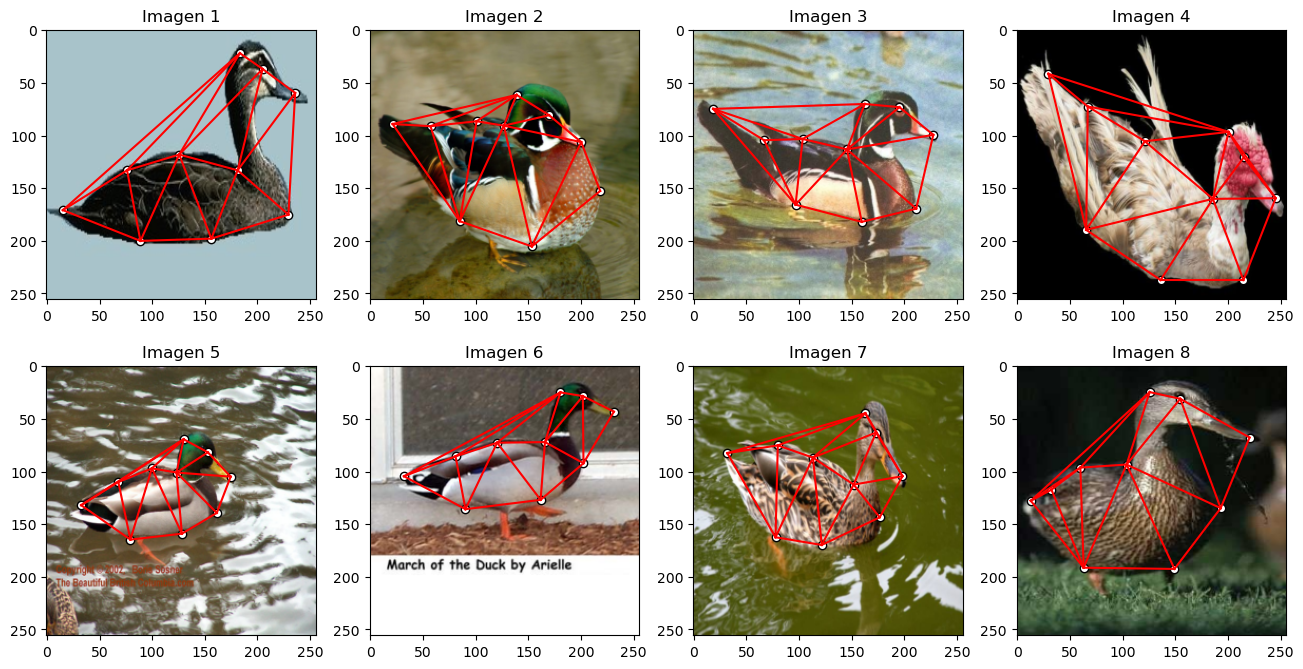

In [7]:
categories = ['Car', 'Face', 'Duck', 'Motorbike', 'Winebottle']

# Cargamos las imágenes
imgs, kpts = cargar_imagenes(categories[2])

#Visualizamos las imágenes
plt.figure(figsize=(16, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.title(f'Imagen {i+1}')

    # calculamos las arsitas
    edges = delaunay_graph(kpts[i])

    plot_image_with_graph(imgs[i], kpts[i], edges)
    
plt.show()

## Ejercicio 2

Reutilizamos las funciones anteriores

### Implementación k-NN

In [8]:
def knn_graph(kpts, k):
    """Constructs a k-NN graph from keypoints."""
    # Implement k-NN graph construction
    pts = kpts.T
    lista_final = []

    # Calculamos las distancias euclidianas
    for i in range(len(pts)):
        punto = pts[i]
        for j in range(i+1, len(pts)):
            punto2 = pts[j]
            # distancia euclidiana correcta
            dist = math.sqrt((punto2[0] - punto[0])**2 + (punto2[1] - punto[1])**2)
            lista_final.append((i,j,dist))

    # Ya tenemos las distancias que hay entre cada punto clave
    edges = set()

    # Para cada punto, buscamos sus k vecinos más cercanos
    for i in range(len(pts)):

        distancias_i = []

        # Buscamos todas las distancias donde participe el punto i
        for (a, b, d) in lista_final:
            if a == i:
                distancias_i.append((d, a, b))
            elif b == i:
                distancias_i.append((d, b, a))

        # Ordenamos por distancia (de menor a mayor)
        distancias_i.sort()

        # Nos quedamos con los k más cercanos
        for t in range(min(k, len(distancias_i))):
            _, u, v = distancias_i[t]
            edges.add((u, v))
            
    return list(edges)

### Visualización de imagenes

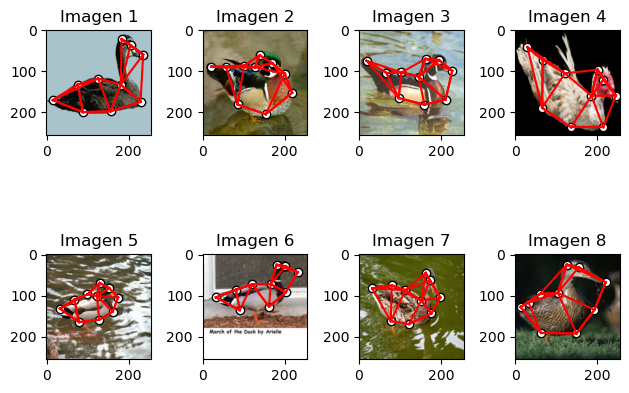

In [10]:
import math 

categories = ['Car', 'Face', 'Duck', 'Motorbike', 'Winebottle']

# Cargamos las imágenes
imgs, kpts = cargar_imagenes(categories[2])

# Usamos el algoritmo k-NN (con k=7)
for i in range(8):
    k = 3
    plt.subplot(2, 4, i + 1)
    plt.title(f'Imagen {i+1}')

    # calculamos las arsitas
    edges = knn_graph(kpts[i], k)

    plot_image_with_graph(imgs[i], kpts[i], edges)

plt.tight_layout()
plt.show()